# 데이터 출처

- 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 소성가공 자원최적화 AI 데이터셋,
- KAIST(울산과학기술원, ㈜리쉐니에), 2022.12.23., www.kamp-ai.kr

# 1. 전처리된 CSV Data Loading 및 기본 조회

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from datetime import datetime

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

<Figure size 1000x800 with 0 Axes>

In [3]:
power_df = pd.read_csv('./data/power_estimate.csv')
# power_augmented_df = pd.read_csv('./data/power_estimate_full_2021.csv')


power_df

,날짜_시간,날짜,시간,15분,30분,45분,60분,최대전력평균,생산량,기온,...,전기요금(계절),요일,일자,월,공장인원,인건비할증,생산구분,추정사용전력량,주말여부,휴일여부
0,2021-01-01 0:00,20210101,0,62,61,61,61,61,0,-3.2,...,109.8,5,1,1,0.000000,1.5,0,40.60,0,1
1,2021-01-01 1:00,20210101,1,96,93,116,113,105,0,-4.5,...,109.8,5,1,1,0.000000,1.5,0,67.00,0,1
2,2021-01-01 2:00,20210101,2,106,96,106,107,104,0,-3.9,...,109.8,5,1,1,0.000000,1.5,0,66.40,0,1
3,2021-01-01 3:00,20210101,3,92,110,110,109,105,0,-4.1,...,109.8,5,1,1,0.000000,1.5,0,67.00,0,1
4,2021-01-01 4:00,20210101,4,108,105,106,108,107,0,-4.6,...,109.8,5,1,1,0.000000,1.5,0,68.20,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,2021-09-14 19:00,20210914,19,152,151,171,139,153,1497,21.7,...,167.2,2,14,9,2.442088,1.5,1,115.83,0,0
6164,2021-09-14 20:00,20210914,20,124,130,128,130,128,45,22.2,...,167.2,2,14,9,0.087891,1.5,2,72.31,0,0
6165,2021-09-14 21:00,20210914,21,134,130,125,124,128,149,22.2,...,167.2,2,14,9,0.290448,1.5,2,72.80,0,0
6166,2021-09-14 22:00,20210914,22,100,109,120,114,111,66,22.0,...,167.2,2,14,9,0.148984,1.5,2,72.41,0,0


In [9]:
# DateTime 형식 변환
power_df['날짜_시간'] = pd.to_datetime(power_df['날짜_시간'])

# 날짜 시간을 인덱스로 구성
power_df = power_df.set_index(keys='날짜_시간', drop=True)

In [4]:

power_df.tail()

,날짜,시간,15분,30분,45분,60분,최대전력평균,생산량,기온,풍속,...,전기요금(계절),요일,일자,월,공장인원,인건비할증,생산구분,추정사용전력량,주말여부,휴일여부
날짜_시간,,,,,,,,,,,,,,,,,,,,,
2021-09-14 19:00:00,20210914,19,152,151,171,139,153,1497,21.7,3.6,...,167.2,2,14,9,2.442088,1.5,1,115.83,0,0
2021-09-14 20:00:00,20210914,20,124,130,128,130,128,45,22.2,4.2,...,167.2,2,14,9,0.087891,1.5,2,72.31,0,0
2021-09-14 21:00:00,20210914,21,134,130,125,124,128,149,22.2,4.3,...,167.2,2,14,9,0.290448,1.5,2,72.80,0,0
2021-09-14 22:00:00,20210914,22,100,109,120,114,111,66,22.0,2.5,...,167.2,2,14,9,0.148984,1.5,2,72.41,0,0
2021-09-14 23:00:00,20210914,23,117,119,112,91,110,405,22.0,2.5,...,167.2,2,14,9,0.922551,1.5,2,74.02,0,0


In [13]:
power_df.groupby('요일')['최대전력평균'].mean()

요일
1    113.305180
2    115.590090
3    107.534722
4    123.045139
5    103.219595
6     51.111486
7     41.344595
Name: 최대전력평균, dtype: float64

- 9월 14일까지만 데이터 존재

In [5]:
power_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6168 entries, 2021-01-01 00:00:00 to 2021-09-14 23:00:00
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   최대전력평균    6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  요일        6168 non-null   int64  
 14  일자        6168 non-null   int64  
 15  월         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비할증     6168 non-null   float64
 18  생산구분      6168 non-null   int64  
 19  추정사용전력량   6168 non-null   float64
 20  주말여부 

In [6]:
power_df[['월','전기요금(계절)']].groupby('월').value_counts()

월  전기요금(계절)
1  109.8       744
2  109.8       672
3  167.2       744
4  167.2       720
5  167.2       744
6  191.6       720
7  191.6       744
8  191.6       744
9  167.2       336
Name: count, dtype: int64

## 1.1 전기요금 구조
- 겨울 : 109.8원, 여름 : 191.6원, 봄/가을 : 167.2원 (kwh 당)
- 시간대별로 구분없이 계절별 단일 요금제 사용

## 1.2 본 노트북 목적
- 전기요금 산정의 기초가 되는 전력 사용량이 없음
- 시간 별 최대전력값을 기초로 생산량, 인력 정보를 활용하여 생산 제품 또는 공정을 구분하고 그에 적합한 전력사용량 산정 방안 도출

# 2. Data Cleansing & Review - 이상치 확인 및 데이터 확인

## 2.1 결측치 확인 및 정리

### 결측치 조사

In [4]:
power_df.isna().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
최대전력평균      0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
요일          0
일자          0
월           0
공장인원        0
인건비할증       0
생산구분        0
추정사용전력량     0
주말여부        0
휴일여부        0
dtype: int64

# 2. 모델 구성 및 학습

## 2.1 Log 적용대상 확인

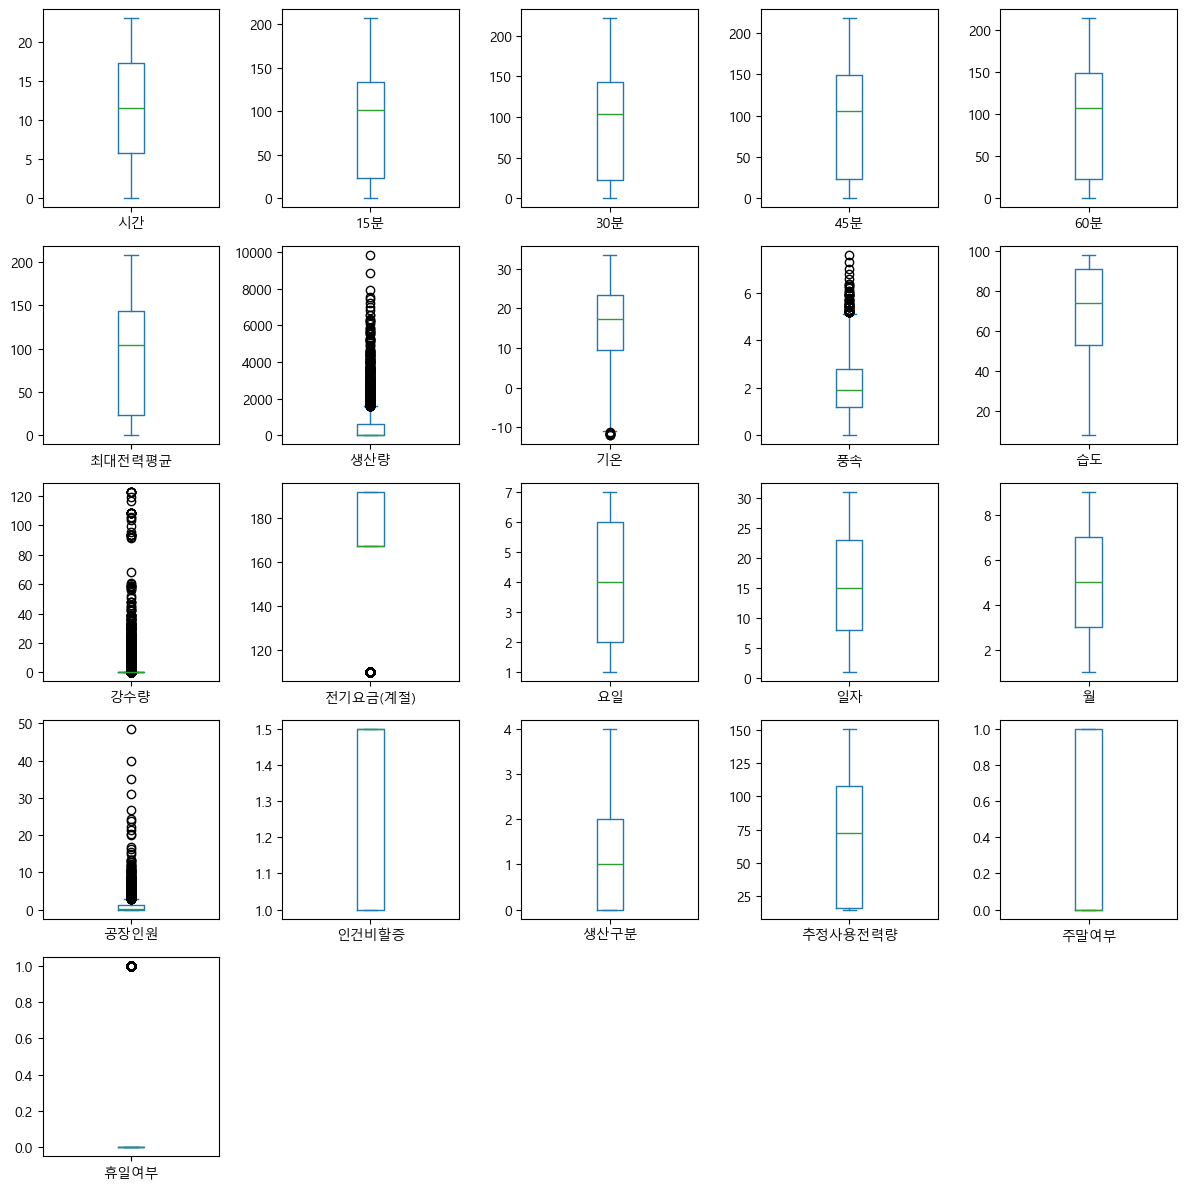

In [4]:
# 일자는 제외
# sns.boxplot(data=power_df.drop(columns=['날짜', '생산량']))
# plt.title('Seaborn Boxplot')

# 한 줄에 5개씩 배치 (열 개수에 맞춰 행 수는 자동 계산)
df = power_df.drop(columns=['날짜'])
df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

* 로그 적용 대상 컬럼 = ['생산량', '강수량', '공장인원', '풍속']

## 2.2. Feature 그룹 생성
1. Blind : 일자 정보 Only
2. Weather : 일자 + 날씨 정보
3. Full : 일자 + 날씨 + 생산 정보

In [10]:
# X
# 일자만으로 예축 (깜깜이 예측)
features_blind = ['월', '일자', '시간', '요일', '주말여부', '휴일여부'] 
# 일자 + 날씨로 예축
features_weather = features_blind + ['기온', '풍속', '습도', '강수량']
# 일자 + 날씨 + 생산계획을 반영하여 예축
features_full = features_weather + ['생산구분', '생산량']
# y
target_features = ['15분', '30분', '45분', '60분']


# C : 행후 생산량에 따른 비용 최적화
cost_features = ['생산량', '전기요금(계절)', '공장인원', '인건비']

features_weather

['월', '일자', '시간', '요일', '주말여부', '휴일여부', '기온', '풍속', '습도', '강수량']

## 2.3. 데이터 분할 : 학습 + 테스트

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


# 1. 독립변수와 종속변수 구분 - 1차 Full Feature
X_Full = power_df[features_full]
y = power_df[target_features] 

# 2. 데이터 전처리 - 우상향 데이터에 대한 로그함수 적용 : Long Tail 데이터 
log_cols = ['생산량', '강수량', '풍속']  # '공장인원'은 제외 : Feature 에 포함되지 않음

print("=== log1p 변환 전후 비교 ===")
for col in log_cols:
    bm, bs = X_Full[col].mean(), X_Full[col].std()
    X_Full[col] = np.log1p(X_Full[col])
    am, as_ = X_Full[col].mean(), X_Full[col].std()
    print(f"  [{col}] 전: mean={bm:.2f} std={bs:.2f} → 후: mean={am:.2f} std={as_:.2f}")


# 3 학습데이터와 테스트 데이터로 분리 - 일자별로 분리
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.1 고유 날짜 추출 (index가 datetime 형식일 때)
unique_dates = power_df.index.normalize().unique() 

# 3.2 날짜를 8:2로 분할
train_dates, test_dates = train_test_split(unique_dates, test_size=0.2, random_state=42)

# 3.3. 날짜 리스트를 기준으로 마스크 생성 및 데이터 분리
train_mask = power_df.index.normalize().isin(train_dates)
test_mask = power_df.index.normalize().isin(test_dates)

## Full Feature
X_Full_train = X_Full.loc[train_mask]
X_Full_test = X_Full.loc[test_mask]

## Weather Feature
X_Weather_train = X_Full_train[features_weather]
X_Weather_test = X_Full_test[features_weather]

## Blind Feature
X_Blind_train = X_Full_train[features_blind]
X_Blind_test = X_Full_test[features_blind]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

=== log1p 변환 전후 비교 ===
  [생산량] 전: mean=467.34 std=857.57 → 후: mean=3.32 std=3.13
  [강수량] 전: mean=2.24 std=9.61 → 후: mean=0.38 std=0.88
  [풍속] 전: mean=2.06 std=1.16 → 후: mean=1.04 std=0.40


C:\Users\Admin\AppData\Local\Temp\ipykernel_11328\2521710098.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_Full[col] = np.log1p(X_Full[col])


In [12]:

## Weather Feature
X_Weather_train

## Blind

,월,일자,시간,요일,주말여부,휴일여부,기온,풍속,습도,강수량
날짜_시간,,,,,,,,,,
2021-01-01 00:00:00,1,1,0,5,0,1,-3.2,1.223775,71,0.000000
2021-01-01 01:00:00,1,1,1,5,0,1,-4.5,0.916291,77,0.000000
2021-01-01 02:00:00,1,1,2,5,0,1,-3.9,1.280934,58,0.000000
2021-01-01 03:00:00,1,1,3,5,0,1,-4.1,1.280934,56,0.000000
2021-01-01 04:00:00,1,1,4,5,0,1,-4.6,1.280934,60,0.000000
...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,9,14,19,2,0,0,21.7,1.526056,85,2.341806
2021-09-14 20:00:00,9,14,20,2,0,0,22.2,1.648659,78,2.341806
2021-09-14 21:00:00,9,14,21,2,0,0,22.2,1.667707,76,2.341806


# 3. Feature 별 학습 및 파라미터 최적화

In [21]:
# 각 변수별 성능 지표 계산
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def get_regression_perfomamce(test, pred) :

    maes = mean_absolute_error(test, pred, multioutput='raw_values')
    rmses = np.sqrt(mean_squared_error(test, pred, multioutput='raw_values'))
    r2s = r2_score(test, pred, multioutput='raw_values')


    perf_df = pd.DataFrame(columns=['mae', 'rmse', 'r2'], index=target_features)

    # 컬럼명과 매칭하여 출력
    for col, mae, rmse, r2 in zip(target_features, maes, rmses, r2s) :
        perf_df.loc[col] = [mae, rmse, r2]
        # print(f"[{col}] MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    
    return perf_df

## 3.1. XGBRegressor 학습 - Full Feature

In [23]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def optimize_regressor(regressor, param_set, train_X, train_y) :

    # 1. RandomizedSearchCV : 전체 조합 중에서 지정한 횟수만큼만 무작위로 골라 테스트
    search = RandomizedSearchCV(
        estimator           = regressor, 
        param_distributions = param_set,
        n_iter              = 100,
        cv                  = 5,
        scoring             = 'neg_mean_squared_error',
        n_jobs              = -1,   
        verbose             = 1,
        random_state        = 42
    )

    # search = GridSearchCV(
    #     estimator           = regressor, 
    #     param_grid          = param_set,
    #     cv                  = 5,
    #     scoring             = 'neg_mean_squared_error',
    #     n_jobs              = -1,   
    #     verbose             = 1
    # )

    # 2. 최적의 파라미터 및 모델 추출
    search.fit(train_X, train_y)

    # 3. 최적의 파라미터 및 모델 추출
    print("\n" + "-"*100)
    print(f"최적 하이퍼파라미터: {search.best_params_}")
    print(f"최고 Score (CV): {search.best_score_:.4f}")
    print("\n" + "-"*100)

    return search.best_estimator_, search.best_params_

In [24]:
from xgboost import XGBRegressor

# 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1
model = XGBRegressor(random_state=42, verbosity=0, n_jobs=1)

# 2. 파라미터 후보 등록
param_xgb = {
    'subsample'       : [0.7, 0.8, 1.0],
    'n_estimators'    : [200, 300, 500],
    'min_child_weight': [2, 3, 5],  # 작을수록 과적합 위험
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# 3 학습 및 최적화
full_regressor, opt_params = optimize_regressor(model, param_xgb, X_Full_train, y_train)

# 4. 예측 수행
y_pred = full_regressor.predict(X_Full_test)

get_regression_perfomamce(y_test, y_pred)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
최고 Score (CV): -1096.6511

----------------------------------------------------------------------------------------------------


,mae,rmse,r2
15분,15.040446,22.797791,0.831176
30분,15.428015,24.155104,0.825764
45분,14.670684,23.907429,0.836587
60분,15.240056,23.799061,0.839505


In [ ]:
# # 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1
# # model = XGBRegressor(random_state=42, verbosity=0, n_jobs=1)

# print(f"이전 하이퍼파라미터: {opt_params}")

# # 2. 파라미터 후보 등록
# param_xgb = {
#     'n_estimators'    : [100, 150, 200],
#     'min_child_weight': [1, 2],  # 작을수록 과적합 위험
#     'max_depth'       : [5, 6, 7],
# }

# # 3 학습 및 최적화
# regressor_2, opt_params_2 = optimize_regressor(regressor, param_xgb, X_Full_train, y_train)

# # 4. 예측 수행
# y_pred_2 = regressor_2.predict(X_Full_test)

# get_regression_perfomamce(y_test, y_pred_2)

이전 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Apps\Miniconda\envs\ml_power\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 18 is smaller than n_iter=100. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'n_estimators': 100, 'min_child_weight': 2, 'max_depth': 7}
최고 R2 Score (CV): -1091.7677

----------------------------------------------------------------------------------------------------


,mae,rmse,r2
15분,15.497449,23.482443,0.820884
30분,15.927861,25.004333,0.813298
45분,15.008931,24.432316,0.829333
60분,15.790944,24.479477,0.830196


* 2차 최적화 결과 동일 또는 낮음

### 최적화 모델 패키징 (Full Feature)

In [77]:
import copy
import joblib

### 최적화 모델 패키징 (Weather Feature)
# regressor_full = copy.deepcopy(regressor)
package_file = './model/xgb_regressor_full.pkl'

joblib.dump(full_regressor, package_file)

print(f"최적 파라미터: {opt_params}")
print(f"모델이 '{package_file}'으로 저장되었습니다.")

최적 파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
모델이 './model/xgb_regressor_full.pkl'으로 저장되었습니다.


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def show_feature_importance(model, feature_list) :
    # 1. 중요도 추출 및 데이터프레임 변환
    importances = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_list, 'Importance': importances})

    # 2. 중요도 순으로 정렬
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # 3. 시각화
    plt.figure(figsize=(10, 6))

    # barplot을 변수 ax에 담습니다.
    ax = sns.barplot(
        x='Importance', 
        y='Feature', 
        data=importance_df, 
        palette='viridis', 
        hue='Feature', 
        legend=False
    )
    
    # 막대 끝에 숫자 값을 추가 (ax.containers[0]은 막대 묶음을 의미)
    # fmt='%.3f'는 소수점 셋째 자리까지 표시하라는 뜻입니다.
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=5)

    plt.title('XGBoost 변수 중요도 (Feature Importance)')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()

    # 4. 수치로 확인
    # print(importance_df)

    return importance_df

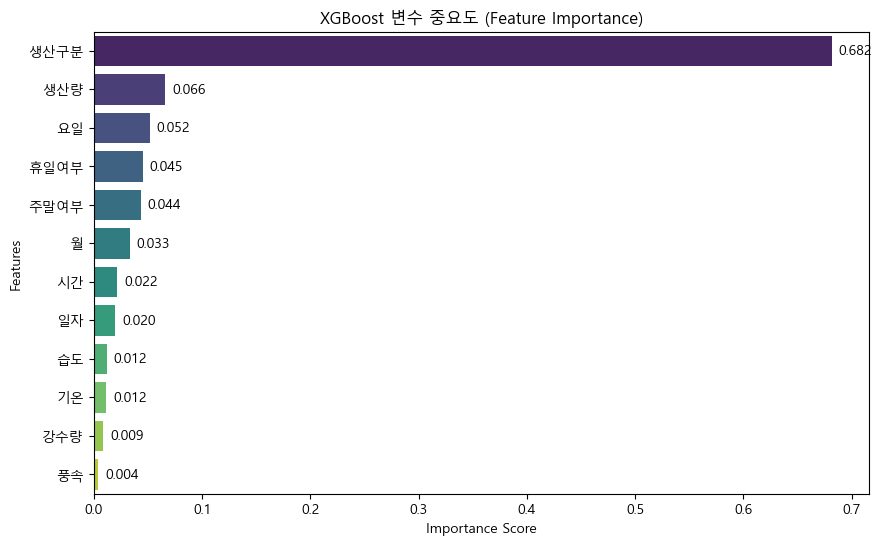

,Feature,Importance
10,생산구분,0.681844
11,생산량,0.066106
3,요일,0.051733
5,휴일여부,0.045362
4,주말여부,0.043505
0,월,0.033377
2,시간,0.021761
1,일자,0.019673
8,습도,0.011865
6,기온,0.011652


In [78]:
show_feature_importance(full_regressor, features_full)

## 3.2. XGBRegressor 학습 - Weather Feature

In [17]:
X_Weather_test

,월,일자,시간,요일,주말여부,휴일여부,기온,풍속,습도,강수량
날짜_시간,,,,,,,,,,
2021-01-07 00:00:00,1,7,0,4,0,0,-2.2,0.641854,53,0.0
2021-01-07 01:00:00,1,7,1,4,0,0,-2.3,0.832909,55,0.0
2021-01-07 02:00:00,1,7,2,4,0,0,-1.2,1.435085,55,0.0
2021-01-07 03:00:00,1,7,3,4,0,0,-1.0,1.386294,55,0.0
2021-01-07 04:00:00,1,7,4,4,0,0,-1.4,1.609438,43,0.0
...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,9,13,19,1,0,0,22.3,1.131402,78,0.0
2021-09-13 20:00:00,9,13,20,1,0,0,22.2,0.832909,78,0.0
2021-09-13 21:00:00,9,13,21,1,0,0,21.9,1.064711,77,0.0


In [35]:
from xgboost import XGBRegressor

# 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1
model = XGBRegressor(random_state=42, verbosity=0, n_jobs=1)

# 2. 파라미터 후보 등록
param_xgb = {
    'subsample'       : [0.7, 0.8, 1.0],
    'n_estimators'    : [200, 300, 500],
    'min_child_weight': [2, 3, 5],  # 작을수록 과적합 위험
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# 3 학습 및 최적화
weather_regressor, opt_params = optimize_regressor(model, param_xgb, X_Weather_train, y_train)

# 4. 예측 수행
y_pred = weather_regressor.predict(X_Weather_test)

get_regression_perfomamce(y_test, y_pred)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
최고 Score (CV): -1454.9435

----------------------------------------------------------------------------------------------------


,mae,rmse,r2
15분,17.325836,25.087322,0.795564
30분,16.291565,24.141935,0.825954
45분,17.569393,25.712093,0.810985
60분,17.665964,25.586679,0.814489


In [ ]:
# from xgboost import XGBRegressor

# # 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1
# print(f"최적 파라미터: {opt_params}")

# # 2. 파라미터 후보 등록
# param_xgb = {
#     'min_child_weight': [1, 2, 3],  # 작을수록 과적합 위험
#     'max_depth'       : [5, 6, 7] 
# }

# # 3 학습 및 최적화
# regressor_2, opt_params_2 = optimize_regressor(regressor, param_xgb, X_Weather_train, y_train)

# # 4. 예측 수행
# y_pred = regressor_2.predict(X_Weather_test)

# get_regression_perfomamce(y_test, y_pred)

* 2차 최적화 실패 : 거의 변화 없거나 오히려 낮음

### 최적화 모델 패키징 (Weather Feature)

In [36]:
import copy, joblib

### 최적화 모델 패키징 (Weather Feature)
# regressor_weather = copy.deepcopy(regressor)
package_file = './model/xgb_regressor_weather.pkl'

joblib.dump(weather_regressor, package_file)

print(f"최적 파라미터: {opt_params}")
print(f"모델이 '{package_file}'으로 저장되었습니다.")

최적 파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
모델이 './model/xgb_regressor_weather.pkl'으로 저장되었습니다.


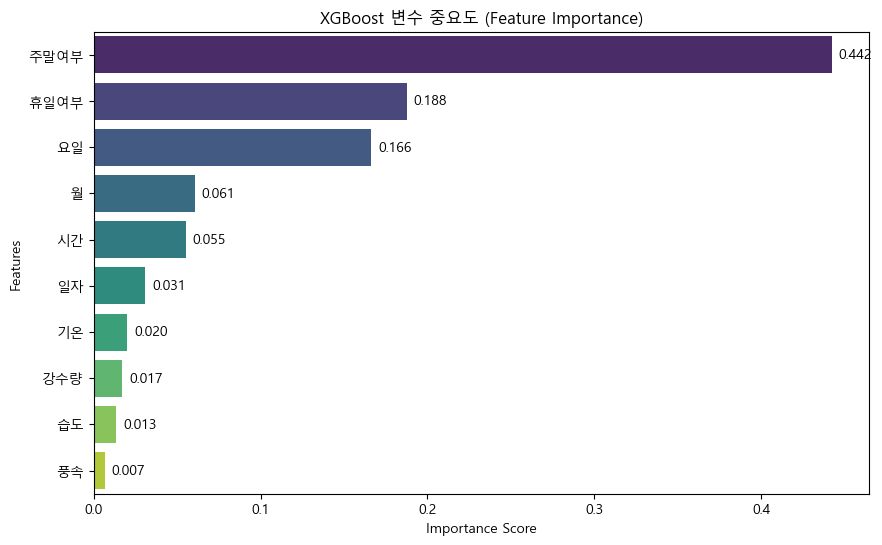

,Feature,Importance
4,주말여부,0.442438
5,휴일여부,0.187556
3,요일,0.166327
0,월,0.060625
2,시간,0.055055
1,일자,0.030898
6,기온,0.020102
9,강수량,0.017083
8,습도,0.013415
7,풍속,0.006502


In [39]:
show_feature_importance(weather_regressor, features_weather)

## 3.3. XGBRegressor 학습 - Blind Feature

In [40]:
X_Blind_train

,월,일자,시간,요일,주말여부,휴일여부
날짜_시간,,,,,,
2021-01-01 00:00:00,1,1,0,5,0,1
2021-01-01 01:00:00,1,1,1,5,0,1
2021-01-01 02:00:00,1,1,2,5,0,1
2021-01-01 03:00:00,1,1,3,5,0,1
2021-01-01 04:00:00,1,1,4,5,0,1
...,...,...,...,...,...,...
2021-09-14 19:00:00,9,14,19,2,0,0
2021-09-14 20:00:00,9,14,20,2,0,0
2021-09-14 21:00:00,9,14,21,2,0,0


In [41]:
from xgboost import XGBRegressor

# 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1
model = XGBRegressor(random_state=42, verbosity=0, n_jobs=1)

# 2. 파라미터 후보 등록
param_xgb = {
    'subsample'       : [0.7, 0.8, 1.0],
    'n_estimators'    : [200, 300, 500],
    'min_child_weight': [2, 3, 5],  # 작을수록 과적합 위험
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# 3 학습 및 최적화
blind_regressor, opt_params = optimize_regressor(model, param_xgb, X_Blind_train, y_train)

# 4. 예측 수행
y_pred = blind_regressor.predict(X_Blind_test)

get_regression_perfomamce(y_test, y_pred)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
최고 Score (CV): -1436.0368

----------------------------------------------------------------------------------------------------


,mae,rmse,r2
15분,16.938395,23.859577,0.815084
30분,16.658625,23.671789,0.832667
45분,17.452549,25.584288,0.81286
60분,17.96162,25.977179,0.808783


In [ ]:
# from xgboost import XGBRegressor

# # 1. 모델 생성 : 개별 모델은 순차처리 n_jobs=1

# # 2. 파라미터 후보 등록
# param_xgb = {
#     'n_estimators'    : [150, 200, 250],
# }

# # 3 학습 및 최적화
# regressor_2 = optimize_regressor(regressor, param_xgb, X_Blind_train, y_train)

# # 4. 예측 수행
# y_pred = regressor_2.predict(X_Blind_test)

# get_regression_perfomamce(y_test, y_pred)

c:\Apps\Miniconda\envs\ml_power\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=30. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'n_estimators': 150}
최고 R2 Score (CV): -1788.1112

----------------------------------------------------------------------------------------------------
[15분] MAE: 21.0900, RMSE: 28.6830, R2: 0.7328
[30분] MAE: 21.1457, RMSE: 28.9101, R2: 0.7504
[45분] MAE: 21.3602, RMSE: 29.7347, R2: 0.7472
[60분] MAE: 21.7048, RMSE: 29.9889, R2: 0.7452


,mae,rmse,r2
15분,21.089979,28.683048,0.732761
30분,21.145653,28.910086,0.750415
45분,21.360239,29.734682,0.747217
60분,21.704847,29.988871,0.745163


In [42]:
import copy, joblib

### 최적화 모델 패키징 (Weather Feature)
# regressor_blind = copy.deepcopy(regressor)
package_file = './model/xgb_regressor_blind.pkl'

joblib.dump(blind_regressor, package_file)

print(f"최적 파라미터: {opt_params}")
print(f"모델이 '{package_file}'으로 저장되었습니다.")

최적 파라미터: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
모델이 './model/xgb_regressor_blind.pkl'으로 저장되었습니다.


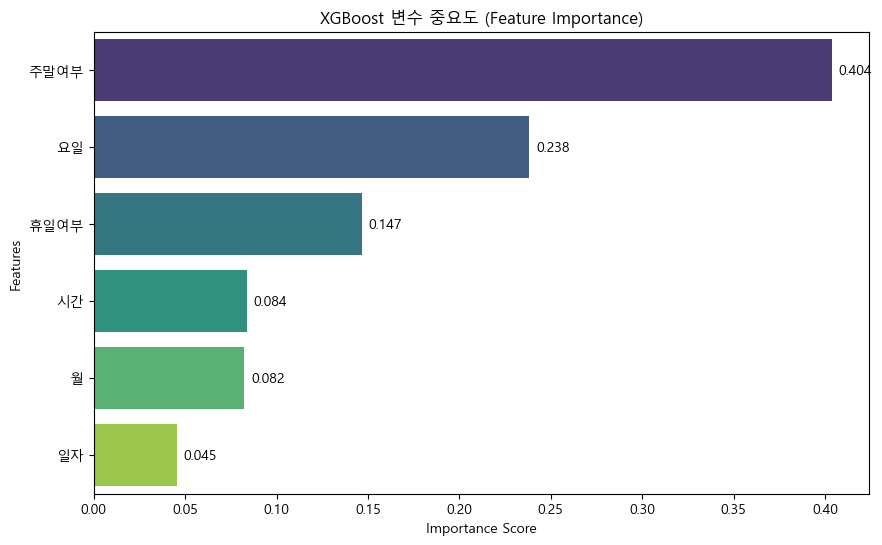

,Feature,Importance
4,주말여부,0.403744
3,요일,0.238093
5,휴일여부,0.146641
2,시간,0.083714
0,월,0.082325
1,일자,0.045484


In [43]:
show_feature_importance(blind_regressor, features_blind)

# 4. 학습모델 및 예측 모델 만들기

In [65]:
X_Full_train

,월,일자,시간,요일,주말여부,휴일여부,기온,풍속,습도,강수량,생산구분,생산량
날짜_시간,,,,,,,,,,,,
2021-01-01 00:00:00,1,1,0,5,0,1,-3.2,1.223775,71,0.000000,0,0.000000
2021-01-01 01:00:00,1,1,1,5,0,1,-4.5,0.916291,77,0.000000,0,0.000000
2021-01-01 02:00:00,1,1,2,5,0,1,-3.9,1.280934,58,0.000000,0,0.000000
2021-01-01 03:00:00,1,1,3,5,0,1,-4.1,1.280934,56,0.000000,0,0.000000
2021-01-01 04:00:00,1,1,4,5,0,1,-4.6,1.280934,60,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,9,14,19,2,0,0,21.7,1.526056,85,2.341806,1,7.311886
2021-09-14 20:00:00,9,14,20,2,0,0,22.2,1.648659,78,2.341806,2,3.828641
2021-09-14 21:00:00,9,14,21,2,0,0,22.2,1.667707,76,2.341806,2,5.010635


In [70]:
import joblib

features_kor = ['월', '일자', '시간', '요일', '주말여부', '휴일여부', '기온', '풍속', '습도', '강수량', '생산구분', '생산량']
features_eng = ['month', 'day', 'hour', 'weekday', 'weekend', 'holiday', 'temperature', 'windspeed', 'humidity', 'rainfall', 'op_code', 'output']


def predict_peak(input_df) :

    # 1 입력 데아터를 통한 
    # 1. 저장된 모델 파일 불러오기
    regressor_full_path = "./model/xgb_regressor_full.pkl"
    regressor_weather_path = "./model/xgb_regressor_weather.pkl"
    regressor_blind_path = "./model/xgb_regressor_blind.pkl"

    work_df = input_df.copy()

    # 2. 입력데아터에 따라 Regressor 선택
    # 2.1. 생산 데아터 확인
    if len(input_df['op_code'].iloc[0]) > 0 :
        xgb_regressor = joblib.load(regressor_full_path)
    elif len(input_df['temperature'].iloc[0]) > 0 :
        xgb_regressor = joblib.load(regressor_weather_path)
        work_df = work_df.drop(columns=['op_code', 'output'], errors='ignore')
    else :
        xgb_regressor = joblib.load(regressor_blind_path)
        work_df = work_df.drop(columns=['temperature', 'windspeed', 'humidity', 'rainfall', 'op_code', 'output'], errors='ignore')

    # 2. 예측 수행 (X_test 등 예측에 사용할 데이터가 필요합니다)
    # 예: pred = xgb_regressor_weather.predict(X_test_weather)

    print("모델 로드 완료 및 예측 준비가 되었습니다.")

    pred_y = xgb_regressor.predict(work_df)

    return pred_y